In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import *
import requests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *
import warnings
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
import torch.optim as optim
from xgboost import train
import CONSTANTS
from functions import *
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import clone
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from xgboostImplementation import XGBoost
import pickle
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(fullDataPath(COIN))
merged = dataSetup(data)[-LIMIT:]
merged

,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,close,gradient
time,,,,,,,,,,
2024-06-27,54298.361946,65288.365054,45.0,0.000000,10530.358988,-273098.307712,61499.718571,9207.959382,61615.39,798.71
2024-06-28,54145.327791,65688.441209,46.0,0.000000,11381.025874,-283628.666701,60846.397143,10270.673373,60313.35,-1302.04
2024-06-29,54049.203970,66151.516030,44.0,0.000000,3199.036501,-272247.640827,60321.551429,12652.300393,60885.67,572.32
2024-06-30,53659.403029,67123.510971,45.0,0.000000,4263.229248,-269048.604326,59944.277143,13116.627323,62668.26,1782.59
2024-07-01,53290.098982,67942.372018,49.0,0.000000,12326.706965,-264785.375077,58970.824286,13267.725496,62830.13,161.87
...,...,...,...,...,...,...,...,...,...,...
2025-06-22,101255.903690,110442.214310,40.0,3.116564,7872.258744,-15479.804635,104624.465714,0.000000,100996.87,-1163.16
2025-06-23,101255.903690,110442.214310,37.0,-3.693263,8904.624392,-7607.545890,104624.465714,0.000000,105419.39,4422.52
2025-06-24,101255.903690,110442.214310,47.0,1.941039,5773.171996,1297.078502,104624.465714,0.000000,106141.00,721.61


# XGBoost Implementation

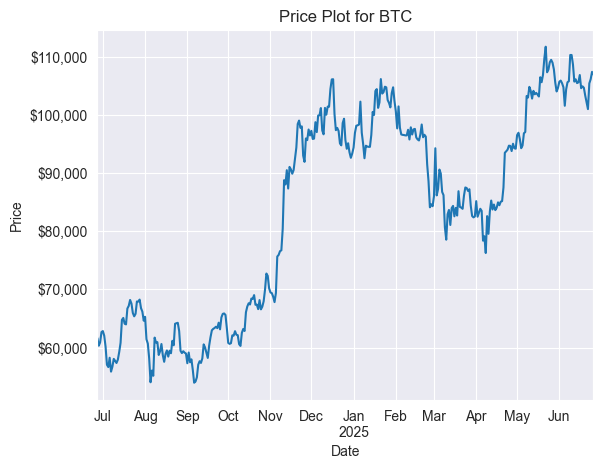

In [3]:
merged['close'].plot.line()
plt.title(f'Price Plot for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
# format y axis to show currency
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

In [4]:
percentage = 0.8
training_cols = trainingCols()
X = merged[training_cols]
y = merged['close']
n = len(data)
merged = transformerDataSetup(merged)
X_train, X_test, y_train, y_test, _, _ = transformerXTrainYTrain(merged[-LIMIT:], testSize=len(merged)-TEST_DAYS)
X_train_norm, X_test_norm, y_train_norm, y_test_norm, sequence_scaler, target_scaler = normalize(X_train, X_test, y_train, y_test)
train_stuff = merged.loc[X_train_norm.index, training_cols]
test_stuff = merged.loc[X_test_norm.index, training_cols]
X_train_norm = pd.concat([X_train_norm, train_stuff], axis=1)
X_test_norm = pd.concat([X_test_norm, test_stuff], axis=1)

In [24]:
import json
import os
import pickle
from datetime import datetime
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.tree import DecisionTreeRegressor
from tqdm import tqdm
from CONSTANTS import TEST_DAYS

class XGBoost(BaseEstimator, RegressorMixin):
    """
    Custom implementation of XGBoost algorithm with gradient boosting
    """

    def __init__(self, base_estimator=None, n_estimators=100, learning_rate=0.1,
                 max_depth=3, subsample=1.0, reg_lambda=1.0, reg_alpha=0.0,
                 random_state=None, output_size=TEST_DAYS):
        """
        Initialize XGBoost implementation

        Parameters:
        -----------
        base_estimator : sklearn estimator, default=None
            Base model to use for boosting. If None, uses DecisionTreeRegressor
        n_estimators : int, default=100
            Number of boosting rounds
        learning_rate : float, default=0.1
            Step size shrinkage to prevent overfitting
        max_depth : int, default=3
            Maximum depth of base estimators
        subsample : float, default=1.0
            Subsample ratio of training instances
        reg_lambda : float, default=1.0
            L2 regularization term
        reg_alpha : float, default=0.0
            L1 regularization term
        random_state : int, default=None
            Random state for reproducibility
        """
        self.output_size = output_size
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.subsample = subsample
        self.reg_lambda = reg_lambda
        self.reg_alpha = reg_alpha
        self.random_state = random_state

        # Initialize containers for models and training history
        self.estimators_ = []
        self.train_scores_ = []
        self.feature_importances_ = None
        self.best_params_ = None
        self.best_score_ = None
        self.tuning_results_ = []
        
        if base_estimator is None:
            self.base_estimator = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=self.random_state
            )

    def _get_base_estimator(self):
        """Get base estimator with proper configuration"""
        if self.base_estimator is None:
            return DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=self.random_state
            )
        else:
            # Clone the base estimator
            return clone(self.base_estimator)

    def _compute_gradients(self, y_true, y_pred):
        """
        Compute vectorized gradients for gradient boosting
        Using squared loss: L(y, F) = (y - F)^2 / 2
        Gradient: -dL/dF = y - F (residuals)
        
        Handles Series of lists and regular arrays
        """
        # Convert y_true if it's a Series of lists
        if isinstance(y_true, pd.Series):
            # Check if Series contains lists
            if len(y_true) > 0 and isinstance(y_true.iloc[0], (list, np.ndarray)):
                y_true = np.array([np.array(row) for row in y_true])
            else:
                y_true = y_true.values
        else:
            y_true = np.array(y_true)
        
        y_pred = np.array(y_pred)
        
        # Handle shape broadcasting for multi-output
        if y_true.ndim == 2 and y_pred.ndim == 1:
            # For single day prediction within multi-output context
            return y_true - y_pred.reshape(-1, 1)
        
        return y_true - y_pred

    def _compute_hessians(self, y_true, y_pred):
        """
        Compute second derivatives (Hessians)
        For squared loss: d²L/dF² = 1
        """
        # Handle Series of lists
        if isinstance(y_true, pd.Series):
            if len(y_true) > 0 and isinstance(y_true.iloc[0], (list, np.ndarray)):
                y_true = np.array([np.array(row) for row in y_true])
            else:
                y_true = y_true.values
        else:
            y_true = np.array(y_true)
            
        return np.ones_like(y_true)

    def _subsample_data(self, X, gradients, hessians):
        """Apply subsampling to training data"""
        if self.subsample < 1.0:
            n_samples = int(len(X) * self.subsample)
            np.random.seed(self.random_state)
            indices = np.random.choice(len(X), n_samples, replace=False)
            return X.iloc[indices], gradients[indices], hessians[indices]
        return X, gradients, hessians

    def fit(self, X, y):
        """
        Fit the XGBoost model

        Parameters:
        -----------
        X : pandas.DataFrame
            Training features (may contain columns with lists of padded numbers)
        y : pandas.Series
            Training targets (Series where each row contains a 1x7 list)

        Returns:
        --------
        self : object
            Returns self for method chaining
        """
        # Process DataFrame with list columns by flattening lists into individual features
        X_processed = []
        column_names = []
        
        for col in X.columns:
            col_data = X[col]
            
            # Check if this column contains lists
            if len(col_data) > 0 and isinstance(col_data.iloc[0], (list, np.ndarray)):
                # Convert all rows to numpy arrays and find max length
                arrays = [np.array(row) for row in col_data]
                max_len = max(len(arr) for arr in arrays)
                
                # Create individual columns for each list element
                for i in range(max_len):
                    feature_values = []
                    for arr in arrays:
                        if i < len(arr):
                            feature_values.append(arr[i])
                        else:
                            feature_values.append(0.0)  # Pad with zeros
                    
                    X_processed.append(feature_values)
                    column_names.append(f"{col}_{i}")
            else:
                # Regular column, add as is
                X_processed.append(col_data.values)
                column_names.append(col)
        
        # Create processed DataFrame
        X_df = pd.DataFrame(np.array(X_processed).T, columns=column_names)
        
        # Handle Series of lists - convert to 2D array
        if isinstance(y, pd.Series):
            if len(y) > 0 and isinstance(y.iloc[0], (list, np.ndarray)):
                y_array = np.array([np.array(row) for row in y])
            else:
                y_array = y.values.reshape(-1, 1)
        else:
            y_array = np.array(y)
            if y_array.ndim == 1:
                y_array = y_array.reshape(-1, 1)

        # Ensure we have output_size output columns
        if y_array.shape[1] != self.output_size:
            if y_array.shape[1] == 1:
                y_array = np.repeat(y_array, self.output_size, axis=1)
            else:
                raise ValueError(f"Target should have {self.output_size} columns for {self.output_size}-day prediction, got {y_array.shape[1]}")

        # Initialize predictions with zeros
        y_pred = np.zeros_like(y_array, dtype=float)

        # Store training scores
        self.train_scores_ = []
        self.estimators_ = []

        # Train separate models for each day (multi-output approach)
        for day in range(self.output_size):
            day_estimators = []
            y_day = y_array[:, day]
            y_pred_day = np.zeros(len(y_day))

            # Boosting iterations for this day
            for i in range(self.n_estimators):
                # Compute gradients and hessians
                gradients = self._compute_gradients(y_day, y_pred_day)
                hessians = self._compute_hessians(y_day, y_pred_day)
                
                # Flatten gradients if needed
                if gradients.ndim > 1:
                    gradients = gradients.flatten()

                # Apply subsampling
                X_sub, grad_sub, hess_sub = self._subsample_data(
                    X_df, gradients, hessians.flatten() if hessians.ndim > 1 else hessians
                )

                # Fit base estimator on gradients
                estimator = self._get_base_estimator()
                estimator.fit(X_sub, grad_sub)

                # Make predictions with current estimator
                tree_pred = estimator.predict(X_df.values)

                # Apply learning rate and update predictions
                y_pred_day += self.learning_rate * tree_pred
                day_estimators.append(estimator)

                # Early stopping check
                if i > 10:
                    current_mse = mean_squared_error(y_day, y_pred_day)
                    if i == 11:
                        prev_mse = current_mse
                    elif abs(current_mse - prev_mse) < 1e-6:
                        break
                    prev_mse = current_mse

            self.estimators_.append(day_estimators)
            y_pred[:, day] = y_pred_day

        # Calculate overall training score using RMSE
        squared_errors = (y_array - y_pred) ** 2
        mse_per_sample = np.mean(squared_errors, axis=1)
        rmse_per_sample = np.sqrt(mse_per_sample)
        overall_rmse = np.mean(rmse_per_sample)
        self.train_scores_.append(overall_rmse)

        # Compute feature importances
        self._compute_feature_importances(X_df)

        return self

    def _compute_feature_importances(self, X):
        """Compute feature importances from all estimators"""
        if len(self.estimators_) > 0 and len(self.estimators_[0]) > 0:
            if hasattr(self.estimators_[0][0], 'feature_importances_'):
                n_features = X.shape[1]
                importances = np.zeros(n_features)
                total_estimators = 0

                for day_estimators in self.estimators_:
                    for estimator in day_estimators:
                        importances += estimator.feature_importances_
                        total_estimators += 1

                self.feature_importances_ = importances / total_estimators

    def predict(self, X):
        """
        Make predictions using the fitted model

        Parameters:
        -----------
        X : pandas.DataFrame or numpy.array
            Features to predict on (may contain columns with lists)

        Returns:
        --------
        predictions : numpy.array or list
            Predicted values (1x7 list for single prediction)
        """
        # Process features the same way as in fit
        X_processed = []
        column_names = []
        
        for col in X.columns:
            col_data = X[col]
            
            # Check if this column contains lists
            if len(col_data) > 0 and isinstance(col_data.iloc[0], (list, np.ndarray)):
                # Convert all rows to numpy arrays and find max length
                arrays = [np.array(row) for row in col_data]
                max_len = max(len(arr) for arr in arrays)
                
                # Create individual columns for each list element
                for i in range(max_len):
                    feature_values = []
                    for arr in arrays:
                        if i < len(arr):
                            feature_values.append(arr[i])
                        else:
                            feature_values.append(0.0)  # Pad with zeros
                    
                    X_processed.append(feature_values)
                    column_names.append(f"{col}_{i}")
            else:
                # Regular column, add as is
                X_processed.append(col_data.values)
                column_names.append(col)
        
        # Create processed DataFrame
        X_df = pd.DataFrame(np.array(X_processed).T, columns=column_names)
        X_array = X_df.values

        # Handle single sample prediction
        if X_array.ndim == 1:
            X_array = X_array.reshape(1, -1)

        predictions = np.zeros((X_array.shape[0], self.output_size))

        # Make predictions for each day
        for day in range(self.output_size):
            day_predictions = np.zeros(X_array.shape[0])

            for estimator in self.estimators_[day]:
                day_predictions += self.learning_rate * estimator.predict(X_array)

            predictions[:, day] = day_predictions

        # Return as 1x7 list for single prediction, or full array for multiple
        if predictions.shape[0] == 1:
            return predictions[0].tolist()  # Return as list of output_size numbers
        else:
            return predictions

    def cross_validate(self, X, y, cv=5, return_train_score=False):
        """
        Perform cross-validation on the model with vectorized RMSE calculation

        Parameters:
        -----------
        X : pandas.DataFrame
            Training features (may contain columns with lists)
        y : pandas.Series
            Training targets (Series of 1x7 lists)
        cv : int, default=5
            Number of cross-validation folds
        return_train_score : bool, default=False
            Whether to return training scores

        Returns:
        --------
        cv_results : dict
            Dictionary containing cross-validation results
        """
        # Handle Series of lists for y
        if isinstance(y, pd.Series) and len(y) > 0 and isinstance(y.iloc[0], (list, np.ndarray)):
            # y is already in the correct format (Series of lists)
            pass
        elif isinstance(y, pd.DataFrame):
            if y.shape[1] != self.output_size:
                raise ValueError(f"y DataFrame must have {self.output_size} columns for {self.output_size}-day prediction, got {y.shape[1]}")
        else:
            raise ValueError("y must be a Series of lists or DataFrame with proper structure")

        kfold = KFold(n_splits=cv, shuffle=True, random_state=self.random_state)

        test_scores = []
        train_scores = [] if return_train_score else None
        splits = list(kfold.split(X))

        for fold, (train_idx, test_idx) in tqdm(enumerate(splits), total=cv, desc="CV Folds"):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Create and fit model for this fold
            model = XGBoost(
                base_estimator=self.base_estimator,
                n_estimators=self.n_estimators,
                learning_rate=self.learning_rate,
                max_depth=self.max_depth,
                subsample=self.subsample,
                reg_lambda=self.reg_lambda,
                reg_alpha=self.reg_alpha,
                random_state=self.random_state,
                output_size=self.output_size
            )

            model.fit(X_train, y_train)
            y_pred_test = model.predict(X_test)
            
            # Convert predictions to proper format for RMSE calculation
            if isinstance(y_pred_test, list) and len(y_test) == 1:
                y_pred_test = np.array([y_pred_test])
            elif not isinstance(y_pred_test, np.ndarray):
                y_pred_test = np.array(y_pred_test)
            
            # Convert y_test to array format
            if isinstance(y_test.iloc[0], (list, np.ndarray)):
                y_test_array = np.array([np.array(row) for row in y_test])
            else:
                y_test_array = y_test.values
            
            # Calculate vectorized RMSE: (y_true-y_pred)^2 ** 0.5
            squared_errors = (y_test_array - y_pred_test) ** 2
            mse_per_sample = np.mean(squared_errors, axis=1)
            rmse_per_sample = np.sqrt(mse_per_sample)
            test_score = np.mean(rmse_per_sample)
            test_scores.append(test_score)

            if return_train_score:
                y_pred_train = model.predict(X_train)
                if isinstance(y_pred_train, list) and len(y_train) == 1:
                    y_pred_train = np.array([y_pred_train])
                elif not isinstance(y_pred_train, np.ndarray):
                    y_pred_train = np.array(y_pred_train)
                    
                if isinstance(y_train.iloc[0], (list, np.ndarray)):
                    y_train_array = np.array([np.array(row) for row in y_train])
                else:
                    y_train_array = y_train.values
                    
                squared_errors_train = (y_train_array - y_pred_train) ** 2
                mse_per_sample_train = np.mean(squared_errors_train, axis=1)
                rmse_per_sample_train = np.sqrt(mse_per_sample_train)
                train_score = np.mean(rmse_per_sample_train)
                train_scores.append(train_score)

        cv_results = {
            'test_scores': np.array(test_scores),
            'test_score_mean': np.mean(test_scores),
            'test_score_std': np.std(test_scores)
        }

        if return_train_score:
            cv_results.update({
                'train_scores': np.array(train_scores),
                'train_score_mean': np.mean(train_scores),
                'train_score_std': np.std(train_scores)
            })

        return cv_results

    def get_params(self, deep=True):
        return {
            'base_estimator': self.base_estimator,
            'n_estimators': self.n_estimators,
            'learning_rate': self.learning_rate,
            'max_depth': self.max_depth,
            'subsample': self.subsample,
            'reg_lambda': self.reg_lambda,
            'reg_alpha': self.reg_alpha,
            'random_state': self.random_state,
            'output_size': self.output_size
        }

    def set_params(self, **params):
        """Set parameters for this estimator"""
        for key, value in params.items():
            setattr(self, key, value)
        return self

    def tune_hyperparameters(self, X, y, param_grid=None, cv=5, scoring='rmse',
                             verbose=True, n_jobs=1):
        """
        Perform grid search cross-validation for hyperparameter tuning

        Parameters:
        -----------
        X : pandas.DataFrame
            Training features
        y : pandas.Series
            Training targets
        param_grid : dict, default=None
            Dictionary with parameters names as keys and lists of parameter settings.
            If None, uses a default parameter grid.
        cv : int, default=5
            Number of cross-validation folds
        scoring : str, default='rmse'
            Scoring metric ('rmse' or 'mse')
        verbose : bool, default=True
            Whether to print progress
        n_jobs : int, default=1
            Number of parallel jobs (placeholder for future implementation)

        Returns:
        --------
        best_params : dict
            Best parameters found
        """
        from sklearn.model_selection import ParameterGrid
        import time

        # Default parameter grid if none provided
        if param_grid is None:
            param_grid = {
                'n_estimators': [50, 100, 150],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 5, 7],
                'subsample': [0.8, 1.0],
                'reg_lambda': [0.1, 1.0, 2.0]
            }

        best_score = float('inf')  # We want to minimize RMSE/MSE
        best_params = None
        all_results = []

        # Iterate through all parameter combinations
        for i, params in enumerate(tqdm(ParameterGrid(param_grid))):

            # Create model with current parameters
            model = XGBoost(**params, random_state=self.random_state)

            # Perform cross-validation using the updated cross_validate method
            cv_results = model.cross_validate(X, y, cv=cv, return_train_score=False)
            mean_score = cv_results['test_score_mean']
            std_score = cv_results['test_score_std']

            # Store results
            result = {
                'params': params.copy(),
                'mean_score': mean_score,
                'std_score': std_score,
                'individual_scores': cv_results['test_scores'].tolist()
            }
            all_results.append(result)

            # Update best parameters
            if mean_score < best_score:
                best_score = mean_score
                best_params = params.copy()

        # Sort results by score
        all_results.sort(key=lambda x: x['mean_score'])

        self.best_params_ = best_params
        self.best_score_ = best_score
        self.tuning_results_ = all_results
        return best_params

    def get_tuning_results(self):
        """
        Get detailed tuning results as a pandas DataFrame

        Returns:
        --------
        results_df : pandas.DataFrame
            DataFrame containing all parameter combinations and their scores
        """
        if not self.tuning_results_:
            print("No tuning results available. Run tune_hyperparameters() first.")
            return None

        # Flatten the results for DataFrame creation
        flattened_results = []
        for result in self.tuning_results_:
            flat_result = result['params'].copy()
            flat_result['mean_score'] = result['mean_score']
            flat_result['std_score'] = result['std_score']
            flattened_results.append(flat_result)

        results_df = pd.DataFrame(flattened_results)
        results_df = results_df.sort_values('mean_score').reset_index(drop=True)
        results_df['rank'] = range(1, len(results_df) + 1)

        return results_df

    def fit_best(self, X, y):
        """
        Fit the model using the best parameters found during tuning

        Parameters:
        -----------
        X : pandas.DataFrame
            Training features
        y : pandas.Series
            Training targets

        Returns:
        --------
        self : object
            Returns self for method chaining
        """
        if self.best_params_ is None:
            raise ValueError("No best parameters available. Run tune_hyperparameters() first.")

        # Update parameters with best found parameters
        for param, value in self.best_params_.items():
            setattr(self, param, value)

        # Fit with best parameters
        return self.fit(X, y)

    def save(self, file):
        with open(file, 'wb') as f:
            pickle.dump(self, f)

    def model_info(self):
        """
        Get information about the current model state

        Returns:
        --------
        info : dict
            Dictionary containing model information
        """
        total_estimators = sum(len(day_est) for day_est in self.estimators_) if self.estimators_ else 0
        
        info = {
            'is_fitted': len(self.estimators_) > 0,
            'output_size': self.output_size,
            'n_days_predicted': self.output_size,
            'total_estimators_fitted': total_estimators,
            'n_estimators_per_day': [len(day_est) for day_est in self.estimators_] if self.estimators_ else [],
            'n_estimators_configured': self.n_estimators,
            'has_feature_importances': self.feature_importances_ is not None,
            'has_tuning_results': len(self.tuning_results_) > 0,
            'best_score': self.best_score_,
            'hyperparameters': self.get_params()
        }

        if self.train_scores_:
            info['final_training_rmse'] = self.train_scores_[-1]

        return info

In [22]:
y_train_norm

time
2024-06-27    [-1.2580243588585254, -1.332928646956036, -1.3...
2024-06-28    [-1.332928646956036, -1.3000039886014791, -1.1...
2024-06-29    [-1.3000039886014791, -1.1974544241336118, -1....
2024-06-30    [-1.1974544241336118, -1.1881423007623302, -1....
2024-07-01    [-1.1881423007623302, -1.2335845653710245, -1....
                                    ...                        
2025-06-15    [1.2722970760287082, 1.344445178108315, 1.2142...
2025-06-16    [1.344445178108315, 1.2142618429516525, 1.2329...
2025-06-17    [1.2142618429516525, 1.232967780033299, 1.2189...
2025-06-18    [1.232967780033299, 1.2189481070513903, 1.1410...
2025-06-19    [1.2189481070513903, 1.1410488900435884, 1.074...
Length: 358, dtype: object

In [ ]:
# Initialize and fit model
xgb_model = XGBoost(
    base_estimator=RandomForestRegressor(n_estimators=50),
    n_estimators=50,
    learning_rate=0.1,
    max_depth=8,
    random_state=42,
)
items = xgb_model.cross_validate(X_train_norm, y_train_norm, cv=5, return_train_score=True)

CV Folds:   0%|          | 0/5 [00:00<?, ?it/s]

In [15]:
raise Exception()

XGBoost(base_estimator=RandomForestRegressor(n_estimators=50), max_depth=8,
        n_estimators=50, random_state=42)

In [17]:
xgb_model.fit(X_train, y_train)
predictions = xgb_model.predict(X_test)
predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
y_test_rescaled = target_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
print('MSE =', mean_squared_error(y_test_rescaled, predictions, squared=False))
predictions

MSE = 22702.937935288614


array([126149.80467508, 124968.91812161, 125257.52128395, 126445.5493465 ,
       130079.86062213, 130627.53191769, 127506.85851262])

<Axes: >

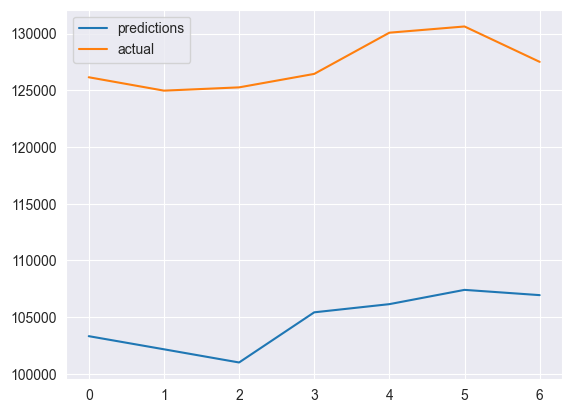

In [18]:
comparison = pd.DataFrame(predictions, y_test_rescaled).reset_index()
comparison.columns = ['predictions', 'actual']
# get latest date from data and add the number of rows in X_test to it
comparison.plot.line()

In [18]:
originalModel = clone(xgb_model, safe=True)

custom_param_grid = {
        'n_estimators': [30, 50, 100],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 5, 8, 15],
        'subsample': [0.8, 1.0]
    }
xgb_model.tune_hyperparameters(X_train, y_train, param_grid=custom_param_grid, cv=5)

100%|██████████| 72/72 [02:05<00:00,  1.74s/it]


{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 30, 'subsample': 1.0}

<Axes: >

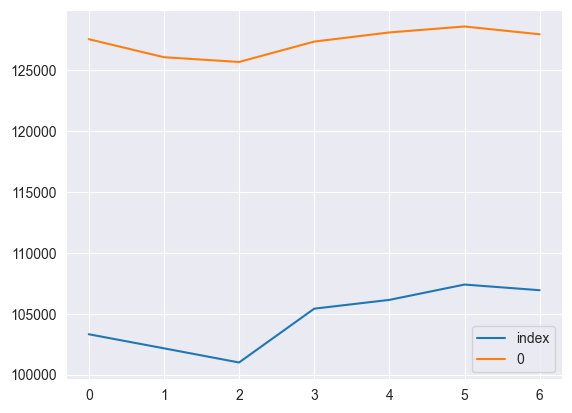

In [10]:
best_model = xgb_model.fit_best(X_train, y_train)
predictions = best_model.predict(X_test)
predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
y_test_rescaled = target_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
comparison = pd.DataFrame(predictions, y_test_rescaled).reset_index()
comparison.plot.line()

In [11]:
comparison.to_csv('plots/XGB_best_comparison.csv', index=True)
best_model.save('models/xgb_best_model.pkl')
originalModel.save('models/xgb_original_model.pkl')

# Create backtracking function from close price

Load Models

In [46]:
transformer = torch.load('models/BTC_full_model.pth')
with open('models/xgb_original_model.pkl', 'rb') as f:
    originalModel = pickle.load(f)

In [54]:
daily_data = merged[-LIMIT:]
daily_data = transformerDataSetup(daily_data)
X_train, X_test, y_train, y_test, _, _ = transformerXTrainYTrain(daily_data[-LIMIT:], testSize=len(daily_data)-TEST_DAYS)
X_train_norm, X_test_norm, y_train_norm, y_test_norm, sequence_scaler, target_scaler = normalize(X_train, X_test, y_train, y_test)

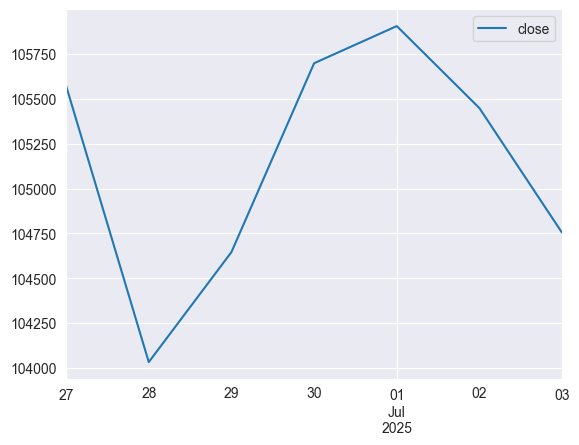

,close
2025-06-27,105572.58
2025-06-28,104033.26
2025-06-29,104645.87
2025-06-30,105697.94
2025-07-01,105904.94
2025-07-02,105447.82
2025-07-03,104753.38


In [55]:
backtracked = predictNextNDaysTransformer(transformer, daily_data, sequence_scaler)
backtracked = pd.DataFrame(backtracked)
backtracked

In [63]:
# Recalculate metrics based on predicted close price from the transformer
backtracked[f'SMA_{TEST_DAYS}'] = backtracked['close'].rolling(TEST_DAYS).mean().fillna(method='bfill')
backtracked['BB_STD'] = backtracked['close'].rolling(TEST_DAYS).std().fillna(method='bfill')
backtracked['BB_Lower'] = backtracked[f'close']-2*backtracked['BB_STD']
backtracked['BB_Upper'] = backtracked[f'close']+2*backtracked['BB_STD']
backtracked['value'] = daily_data['value'].iloc[0]
backtracked

,close,SMA_7,BB_STD,BB_Lower,BB_Upper,value
2025-06-27,105572.58,105150.827143,682.64207,104207.29586,106937.86414,45.0
2025-06-28,104033.26,105150.827143,682.64207,102667.97586,105398.54414,45.0
2025-06-29,104645.87,105150.827143,682.64207,103280.58586,106011.15414,45.0
2025-06-30,105697.94,105150.827143,682.64207,104332.65586,107063.22414,45.0
2025-07-01,105904.94,105150.827143,682.64207,104539.65586,107270.22414,45.0
2025-07-02,105447.82,105150.827143,682.64207,104082.53586,106813.10414,45.0
2025-07-03,104753.38,105150.827143,682.64207,103388.09586,106118.66414,45.0


In [73]:
backtracked_norm, _, _, _, sequence_scaler, target_scaler = normalize_regular(backtracked, backtracked, backtracked['close'], backtracked['close'])
predictions = originalModel.predict(backtracked_norm[trainingCols])
predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
predictions

array([105150.82714286, 105150.82714286, 105150.82714286, 105150.82714286,
       105150.82714286, 105150.82714286, 105150.82714286])

In [74]:
backtracked['close'].mean()

105150.82714285713